In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 64.9 MB/s eta 0:00:00


In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
!pip install folium mapclassify

In [ ]:
import pandas as pd
dong_df = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/행정동.csv', encoding='utf-8', header=None)
dong_df.head()

,0,1,2
0,행정동코드,자치구,행정동
1,11010530,종로구,사직동
2,11010540,종로구,삼청동
3,11010550,종로구,부암동
4,11010560,종로구,평창동


In [ ]:
dong_df.columns = dong_df.iloc[0]

# 2️⃣ 첫 행 제거
dong_df = dong_df[1:].reset_index(drop=True)

dong_df.head()

,행정동코드,자치구,행정동
0,11010530,종로구,사직동
1,11010540,종로구,삼청동
2,11010550,종로구,부암동
3,11010560,종로구,평창동
4,11010570,종로구,무악동


# 화재발생 데이터



In [ ]:
df = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/행정동별_화재발생.csv', encoding='utf-8', header=None)
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,동별(1),동별(2),동별(3),2020,2020,2020,2021,2021,2021,2022,2022,2022,2023,2023,2023,2024,2024,2024
1,동별(1),동별(2),동별(3),합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
2,동별(1),동별(2),동별(3),주거,주거,주거,주거,주거,주거,주거,주거,주거,주거,주거,주거,주거,주거,주거
3,동별(1),동별(2),동별(3),단독주택,공동주택,기타주택,단독주택,공동주택,기타주택,단독주택,공동주택,기타주택,단독주택,공동주택,기타주택,단독주택,공동주택,기타주택
4,합계,종로구,소계,40,32,2,31,26,2,20,29,1,23,15,3,19,30,2
5,합계,종로구,사직동,3,3,-,-,1,-,1,-,-,-,1,-,1,1,-
6,합계,종로구,삼청동,2,-,-,1,-,-,-,-,-,-,-,-,-,1,-
7,합계,종로구,부암동,1,-,-,-,2,-,1,1,-,3,-,-,-,1,-
8,합계,종로구,평창동,5,8,-,4,2,-,4,1,-,3,5,1,4,1,-
9,합계,종로구,무악동,-,1,-,-,2,-,-,4,-,-,1,-,-,2,-


In [ ]:
df = df.iloc[4:, 1:].reset_index(drop=True)
df.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,종로구,소계,40,32,2,31,26,2,20,29,1,23,15,3,19,30,2
1,종로구,사직동,3,3,-,-,1,-,1,-,-,-,1,-,1,1,-
2,종로구,삼청동,2,-,-,1,-,-,-,-,-,-,-,-,-,1,-
3,종로구,부암동,1,-,-,-,2,-,1,1,-,3,-,-,-,1,-
4,종로구,평창동,5,8,-,4,2,-,4,1,-,3,5,1,4,1,-


In [ ]:
columns = ['구', '동']
for year in range(2020, 2025):
    columns.extend([f'{year}_단독', f'{year}_공동', f'{year}_기타'])
df.columns = columns

df.head()

,구,동,2020_단독,2020_공동,2020_기타,2021_단독,2021_공동,2021_기타,2022_단독,2022_공동,2022_기타,2023_단독,2023_공동,2023_기타,2024_단독,2024_공동,2024_기타
0,종로구,소계,40,32,2,31,26,2,20,29,1,23,15,3,19,30,2
1,종로구,사직동,3,3,-,-,1,-,1,-,-,-,1,-,1,1,-
2,종로구,삼청동,2,-,-,1,-,-,-,-,-,-,-,-,-,1,-
3,종로구,부암동,1,-,-,-,2,-,1,1,-,3,-,-,-,1,-
4,종로구,평창동,5,8,-,4,2,-,4,1,-,3,5,1,4,1,-


In [ ]:
# 합계, 소계 포함 행 제거
df = df[~df['구'].isin(['합계', '소계'])]
df = df[~df['동'].isin(['합계', '소계'])]
df.head()

,구,동,2020_단독,2020_공동,2020_기타,2021_단독,2021_공동,2021_기타,2022_단독,2022_공동,2022_기타,2023_단독,2023_공동,2023_기타,2024_단독,2024_공동,2024_기타
1,종로구,사직동,3,3,-,-,1,-,1,-,-,-,1,-,1,1,-
2,종로구,삼청동,2,-,-,1,-,-,-,-,-,-,-,-,-,1,-
3,종로구,부암동,1,-,-,-,2,-,1,1,-,3,-,-,-,1,-
4,종로구,평창동,5,8,-,4,2,-,4,1,-,3,5,1,4,1,-
5,종로구,무악동,-,1,-,-,2,-,-,4,-,-,1,-,-,2,-


In [ ]:
# '-' -> 0, 정수형 변환
cols_to_fix = [c for c in df.columns if c not in ['구', '동']]
for col in cols_to_fix:
    df[col] = df[col].replace('-', '0').fillna('0').astype(int)

df.head()

,구,동,2020_단독,2020_공동,2020_기타,2021_단독,2021_공동,2021_기타,2022_단독,2022_공동,2022_기타,2023_단독,2023_공동,2023_기타,2024_단독,2024_공동,2024_기타
1,종로구,사직동,3,3,0,0,1,0,1,0,0,0,1,0,1,1,0
2,종로구,삼청동,2,0,0,1,0,0,0,0,0,0,0,0,0,1,0
3,종로구,부암동,1,0,0,0,2,0,1,1,0,3,0,0,0,1,0
4,종로구,평창동,5,8,0,4,2,0,4,1,0,3,5,1,4,1,0
5,종로구,무악동,0,1,0,0,2,0,0,4,0,0,1,0,0,2,0


In [ ]:
# 6. 연도별 합산 및 5개년 평균 산출 (분석의 핵심)
df['단독주택_5년합계'] = df[[f'{y}_단독' for y in range(2020, 2025)]].sum(axis=1)
df['공동주택_5년합계'] = df[[f'{y}_공동' for y in range(2020, 2025)]].sum(axis=1)
df['기타주택_5년합계'] = df[[f'{y}_기타' for y in range(2020, 2025)]].sum(axis=1)

# 7. 최종 필요한 컬럼만 추출
final_df = df[['구', '동', '단독주택_5년합계', '공동주택_5년합계']]

In [ ]:
# 인덱스 재정렬 및 결과 확인
final_df = final_df.reset_index(drop=True)
print("--- 전처리 완료 데이터 (상위 5개) ---")
print(final_df.head())

--- 전처리 완료 데이터 (상위 5개) ---
     구    동  단독주택_5년합계  공동주택_5년합계
0  종로구  사직동          5          6
1  종로구  삼청동          3          1
2  종로구  부암동          5          4
3  종로구  평창동         20         17
4  종로구  무악동          0         10


In [ ]:
# 1. 단독주택_5년합계 기준 내림차순 정렬 후 상위 10개 추출
top_10_houses = final_df.sort_values(by='단독주택_5년합계', ascending=False).head(10)

# 2. '자치구'와 '행정동' 컬럼만 선택하여 출력
# index를 제거하고 깔끔하게 보기 위해 .reset_index(drop=True)를 사용합니다.
result = top_10_houses[['구', '동', '단독주택_5년합계']].reset_index(drop=True)

print("--- 서울시 단독주택 밀집 지역 TOP 10 ---")
print(result)

--- 서울시 단독주택 밀집 지역 TOP 10 ---
      구     동  단독주택_5년합계
0   강남구  논현1동         45
1   광진구   화양동         37
2   관악구   신사동         35
3   금천구  독산3동         35
4   구로구  구로2동         35
5   용산구   보광동         33
6   중랑구  망우본동         33
7   중랑구  중화2동         32
8   금천구  시흥1동         32
9  영등포구  대림2동         31


In [ ]:
# 1. 공동주택_5년합계 기준 내림차순 정렬 후 상위 10개 추출
top_10_houses = final_df.sort_values(by='공동주택_5년합계', ascending=False).head(10)

# 2. '자치구'와 '행정동' 컬럼만 선택하여 출력
# index를 제거하고 깔끔하게 보기 위해 .reset_index(drop=True)를 사용합니다.
result = top_10_houses[['구', '동', '공동주택_5년합계']].reset_index(drop=True)

print("--- 서울시 공동주택 밀집 지역 TOP 10 ---")
print(result)

--- 서울시 공동주택 밀집 지역 TOP 10 ---
      구       동  공동주택_5년합계
0   송파구     삼전동         44
1  서대문구   북가좌2동         42
2   강남구    역삼1동         41
3   강남구    논현1동         39
4   강북구     인수동         38
5   송파구     오금동         38
6   노원구  중계2.3동         38
7   강서구    화곡1동         38
8   금천구    독산1동         37
9   서초구    양재1동         36


In [ ]:
import numpy as np
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   구          429 non-null    object
 1   동          429 non-null    object
 2   단독주택_5년합계  429 non-null    int64 
 3   공동주택_5년합계  429 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 13.5+ KB
None


In [ ]:
df_gangil = final_df[final_df['동'] == '강일동']
df_gangil


,구,동,단독주택_5년합계,공동주택_5년합계
408,강동구,강일동,0,2
426,강동구,강일동,0,15


In [ ]:
# 숫자 컬럼만 선택 (자동으로 '구', '동' 제외됨)
numeric_cols = final_df.select_dtypes(include='number').columns

# 433번째 행 → 451번째 행에 더하기
final_df.loc[426, numeric_cols] += final_df.loc[408, numeric_cols]

final_df = final_df.drop(index=408)

In [ ]:
df_gangil = final_df[final_df['동'] == '강일동']
df_gangil


,구,동,단독주택_5년합계,공동주택_5년합계
426,강동구,강일동,0,17


In [ ]:
dongs = sorted(dong_df['행정동'])
fire_dongs = sorted(final_df['동'])

print(len(dongs))
print(len(fire_dongs))

dong_list=set(dongs)
fire_dongs=set(fire_dongs)

only_in_fire = fire_dongs - dong_list
print(f"--- 화재 데이터에만 있는 동 ({len(only_in_fire)}개) ---")
print(sorted(list(only_in_fire)))

only_in_dong = dong_list - fire_dongs
print(f"--- 화재 데이터에 없는 동 ({len(only_in_dong)}개) ---")
print(sorted(list(only_in_dong)))

425
428
--- 화재 데이터에만 있는 동 (10개) ---
['금호2.3가동', '면목3.8동', '상계3.4동', '상계6.7동', '상일1동', '상일2동', '일원2동', '종로1.2.3.4가동', '종로5.6가동', '중계2.3동']
--- 화재 데이터에 없는 동 (7개) ---
['금호2·3가동', '면목3·8동', '상계3·4동', '상계6·7동', '종로1·2·3·4가동', '종로5·6가동', '중계2·3동']


In [ ]:
def finalize_dong_names(df, col_name):
    # 1. 양쪽의 공백 제거
    df[col_name] = df[col_name].str.strip()

    # 2. 특수문자 통일 (마침표를 가운뎃점으로)
    df[col_name] = df[col_name].str.replace('.', '·', regex=False)

    return df

final_df = finalize_dong_names(final_df, '동')


In [ ]:
df_check = final_df[final_df['동'].isin(['상일동','상일1동', '상일2동', '강일동','개포3동','일원2동'])]
df_check

,구,동,단독주택_5년합계,공동주택_5년합계
359,강남구,개포3동,0,4
374,강남구,일원2동,0,3
409,강동구,상일동,1,3
426,강동구,강일동,0,17
427,강동구,상일1동,4,10
428,강동구,상일2동,0,3


In [ ]:
numeric_cols = final_df.select_dtypes(include='number').columns

final_df.loc[359, numeric_cols] += final_df.loc[374, numeric_cols]
final_df.loc[409, numeric_cols] += final_df.loc[427, numeric_cols]
final_df.loc[426, numeric_cols] += final_df.loc[428, numeric_cols]

# 삭제
final_df = final_df.drop(index=[374, 427, 428])

# 인덱스 정리
final_df = final_df.reset_index(drop=True)

In [ ]:
dongs = sorted(dong_df['행정동'])
fire_dongs = sorted(final_df['동'])

print(len(dongs))
print(len(fire_dongs))

dong_list=set(dongs)
fire_dongs=set(fire_dongs)

only_in_fire = fire_dongs - dong_list
print(f"--- 화재 데이터에만 있는 동 ({len(only_in_fire)}개) ---")
print(sorted(list(only_in_fire)))

only_in_dong = dong_list - fire_dongs
print(f"--- 화재 데이터에 없는 동 ({len(only_in_dong)}개) ---")
print(sorted(list(only_in_dong)))

425
425
--- 화재 데이터에만 있는 동 (0개) ---
[]
--- 화재 데이터에 없는 동 (0개) ---
[]


In [ ]:
fire_cols = ['단독주택_5년합계', '공동주택_5년합계']
final_df[fire_cols].describe()

,단독주택_5년합계,공동주택_5년합계
count,425.000000,425.000000
mean,9.618824,14.877647
std,8.363252,8.097233
min,0.000000,0.000000
25%,3.000000,9.000000
50%,8.000000,14.000000
75%,15.000000,20.000000
max,45.000000,44.000000


In [ ]:
# 내림차순 정렬 확인 (가장 위험한 동네 순)
final_df.sort_values(by='단독주택_5년합계', ascending=False).head(10)

,구,동,단독주택_5년합계,공동주택_5년합계
360,강남구,논현1동,45,39
65,광진구,화양동,37,18
279,금천구,독산3동,35,20
329,관악구,신사동,35,6
272,구로구,구로2동,35,14
109,중랑구,망우본동,33,21
43,용산구,보광동,33,10
281,금천구,시흥1동,32,19
101,중랑구,중화2동,32,17
298,영등포구,대림2동,31,8


In [ ]:
final_df.sort_values(by='공동주택_5년합계', ascending=False).head(10)

,구,동,단독주택_5년합계,공동주택_5년합계
393,송파구,삼전동,18,44
201,서대문구,북가좌2동,17,42
366,강남구,역삼1동,31,41
360,강남구,논현1동,45,39
174,노원구,중계2·3동,0,38
142,강북구,인수동,23,38
258,강서구,화곡1동,15,38
389,송파구,오금동,6,38
277,금천구,독산1동,11,37
355,서초구,양재1동,7,36


# 주택 종류 데이터

In [ ]:
import pandas as pd
import numpy as np

df_housing = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/행정동별_주택종류.csv', encoding='utf-8', header=None)
df_housing.head(10)


,0,1,2,3,4,5,6
0,동별(1),동별(2),동별(3),2020,2020,2020,2020
1,동별(1),동별(2),동별(3),종류별 주택수,종류별 주택수,종류별 주택수,종류별 주택수
2,동별(1),동별(2),동별(3),단독주택,아파트,연립주택,다세대주택
3,서울시,종로구,소계,12259,15688,5460,12540
4,서울시,종로구,사직동,650,1591,78,411
5,서울시,종로구,삼청동,644,X,19,37
6,서울시,종로구,부암동,1033,121,903,976
7,서울시,종로구,평창동,1553,1009,2186,1139
8,서울시,종로구,무악동,48,2703,55,46
9,서울시,종로구,교남동,237,2526,88,1060


In [ ]:
df_housing = df_housing.iloc[3:, 1:].reset_index(drop=True)
df_housing.head()

,1,2,3,4,5,6
0,종로구,소계,12259,15688,5460,12540
1,종로구,사직동,650,1591,78,411
2,종로구,삼청동,644,X,19,37
3,종로구,부암동,1033,121,903,976
4,종로구,평창동,1553,1009,2186,1139


In [ ]:
# 불필요한 행 제거
df_housing = df_housing.iloc[:, [0, 1, 2, 3, 4, 5]]
df_housing.columns = ['구', '동', '단독주택', '아파트', '연립주택', '다세대주택']

df_housing = df_housing[~df_housing['구'].isin(['합계', '소계'])]
df_housing = df_housing[~df_housing['동'].isin(['합계', '소계'])]
df_housing.head()

,구,동,단독주택,아파트,연립주택,다세대주택
1,종로구,사직동,650,1591,78,411
2,종로구,삼청동,644,X,19,37
3,종로구,부암동,1033,121,903,976
4,종로구,평창동,1553,1009,2186,1139
5,종로구,무악동,48,2703,55,46


In [ ]:
cols_to_fix = ['단독주택', '아파트', '연립주택', '다세대주택']
for col in cols_to_fix:
    # X, -, 공백 등을 모두 0으로 치환
    df_housing[col] = df_housing[col].replace(['X', '-', ' '], '0')
    # 혹시 모를 결측치(NaN)도 0으로 채운 후 정수형 변환
    df_housing[col] = pd.to_numeric(df_housing[col], errors='coerce').fillna(0).astype(int)

df_housing.head()

,구,동,단독주택,아파트,연립주택,다세대주택
1,종로구,사직동,650,1591,78,411
2,종로구,삼청동,644,0,19,37
3,종로구,부암동,1033,121,903,976
4,종로구,평창동,1553,1009,2186,1139
5,종로구,무악동,48,2703,55,46


In [ ]:
df_housing = df_housing.reset_index(drop=True)
print(df_housing.head())

     구    동  단독주택   아파트  연립주택  다세대주택
0  종로구  사직동   650  1591    78    411
1  종로구  삼청동   644     0    19     37
2  종로구  부암동  1033   121   903    976
3  종로구  평창동  1553  1009  2186   1139
4  종로구  무악동    48  2703    55     46


In [ ]:
print(df_housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구       425 non-null    object
 1   동       425 non-null    object
 2   단독주택    425 non-null    int64 
 3   아파트     425 non-null    int64 
 4   연립주택    425 non-null    int64 
 5   다세대주택   425 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 20.1+ KB
None


In [ ]:
house_cols = ['단독주택', '아파트', '연립주택', '다세대주택']
df_housing[house_cols].describe()

,단독주택,아파트,연립주택,다세대주택
count,425.000000,425.000000,425.000000,425.000000
mean,722.498824,4170.988235,260.141176,1873.096471
std,556.289557,3235.590163,312.454138,1864.117118
min,0.000000,0.000000,0.000000,0.000000
25%,271.000000,1510.000000,61.000000,467.000000
50%,625.000000,3405.000000,178.000000,1398.000000
75%,1070.000000,6158.000000,355.000000,2790.000000
max,3011.000000,16634.000000,3213.000000,11128.000000


In [ ]:
dongs = sorted(dong_df['행정동'])
house = sorted(df_housing['동'])

print(len(dongs))
print(len(house))

dong_list=set(dongs)
house=set(house)

only_in_house = house - dong_list
print(f"--- 화재 데이터에만 있는 동 ({len(only_in_house)}개) ---")
print(sorted(list(only_in_house)))

only_in_dong = dong_list - house
print(f"--- 화재 데이터에 없는 동 ({len(only_in_dong)}개) ---")
print(sorted(list(only_in_dong)))

425
425
--- 화재 데이터에만 있는 동 (8개) ---
['금호2.3가동', '면목3.8동', '상계3.4동', '상계6.7동', '일원2동', '종로1.2.3.4가동', '종로5.6가동', '중계2.3동']
--- 화재 데이터에 없는 동 (8개) ---
['개포3동', '금호2·3가동', '면목3·8동', '상계3·4동', '상계6·7동', '종로1·2·3·4가동', '종로5·6가동', '중계2·3동']


In [ ]:
def finalize_dong_names(df, col_name):
    # 1. 양쪽의 공백 제거
    df[col_name] = df[col_name].str.strip()

    # 2. 특수문자 통일 (마침표를 가운뎃점으로)
    df[col_name] = df[col_name].str.replace('.', '·', regex=False)

    return df

df_housing = finalize_dong_names(df_housing, '동')


In [ ]:
df_check = df_housing[df_housing['동'].isin(['상일동','상일1동', '상일2동', '강일동','개포3동','일원2동'])]
df_check

,구,동,단독주택,아파트,연립주택,다세대주택
373,강남구,일원2동,0,6678,0,0
407,강동구,강일동,31,11638,0,76
408,강동구,상일동,242,8953,582,658


In [ ]:
df_housing.loc[df_housing['동'] == '일원2동', '동'] = '개포3동'

In [ ]:
dongs = sorted(dong_df['행정동'])
house = sorted(df_housing['동'])

print(len(dongs))
print(len(house))

dong_list=set(dongs)
house=set(house)

only_in_house = house - dong_list
print(f"--- 주택 데이터에만 있는 동 ({len(only_in_house)}개) ---")
print(sorted(list(only_in_house)))

only_in_dong = dong_list - house
print(f"--- 주택 데이터에 없는 동 ({len(only_in_dong)}개) ---")
print(sorted(list(only_in_dong)))

425
425
--- 주택 데이터에만 있는 동 (0개) ---
[]
--- 주택 데이터에 없는 동 (0개) ---
[]


In [ ]:
# 1. 전체 공동주택 합계 계산 (분모)
# 아파트 + 연립주택 + 다세대주택
df_housing['전체_공동주택_수'] = df_housing['아파트'] + df_housing['연립주택'] + df_housing['다세대주택']

# 2. 빌라 비율(연립+다세대 / 전체 공동주택) 컬럼 생성
# 분모가 0인 경우(공동주택이 없는 특수 지역) 에러 방지를 위해 fillna(0) 처리
df_housing['빌라_보정계수'] = (df_housing['연립주택'] + df_housing['다세대주택']) / df_housing['전체_공동주택_수']
df_housing['빌라_보정계수'] = df_housing['빌라_보정계수'].fillna(0)

df_housing.head()

,구,동,단독주택,아파트,연립주택,다세대주택,전체_공동주택_수,빌라_보정계수
0,종로구,사직동,650,1591,78,411,2080,0.235096
1,종로구,삼청동,644,0,19,37,56,1.000000
2,종로구,부암동,1033,121,903,976,2000,0.939500
3,종로구,평창동,1553,1009,2186,1139,4334,0.767190
4,종로구,무악동,48,2703,55,46,2804,0.036020


In [ ]:
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   구          425 non-null    object 
 1   동          425 non-null    object 
 2   단독주택       425 non-null    int64  
 3   아파트        425 non-null    int64  
 4   연립주택       425 non-null    int64  
 5   다세대주택      425 non-null    int64  
 6   전체_공동주택_수  425 non-null    int64  
 7   빌라_보정계수    425 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 26.7+ KB


In [ ]:
df_housing.sort_values(by='빌라_보정계수', ascending=False).head(10)

,구,동,단독주택,아파트,연립주택,다세대주택,전체_공동주택_수,빌라_보정계수
6,종로구,가회동,731,0,137,719,856,1.000000
1,종로구,삼청동,644,0,19,37,56,1.000000
71,광진구,능동,786,21,72,1620,1713,0.987741
122,성북구,장위1동,1482,90,462,4010,4562,0.980272
44,용산구,청파동,1837,74,455,3186,3715,0.980081
104,중랑구,망우3동,1348,61,111,2018,2190,0.972146
393,송파구,삼전동,477,479,284,10168,10931,0.956180
148,도봉구,방학2동,1072,234,845,3907,4986,0.953069
70,광진구,중곡4동,1508,314,666,4746,5726,0.945162
2,종로구,부암동,1033,121,903,976,2000,0.939500


In [ ]:
df_housing.sort_values(by='빌라_보정계수').head(10)

,구,동,단독주택,아파트,연립주택,다세대주택,전체_공동주택_수,빌라_보정계수
420,강동구,둔촌1동,5,0,0,0,0,0.0
395,송파구,가락1동,0,9716,0,0,9716,0.0
388,송파구,오륜동,0,5540,0,0,5540,0.0
373,강남구,개포3동,0,6678,0,0,6678,0.0
402,송파구,잠실7동,0,3198,0,0,3198,0.0
401,송파구,잠실6동,0,5372,0,0,5372,0.0
400,송파구,잠실4동,0,6864,0,0,6864,0.0
398,송파구,문정2동,0,5606,0,0,5606,0.0
374,강남구,수서동,58,7185,0,0,7185,0.0
345,서초구,반포본동,0,3660,0,0,3660,0.0


# Merge

In [ ]:
fire = sorted(final_df['동'])
house = sorted(df_housing['동'])

print(len(fire))
print(len(house))

fire=set(fire)
house=set(house)

only_in_house = house - fire
print(f"--- 집 데이터에만 있는 동 ({len(only_in_house)}개) ---")
print(sorted(list(only_in_house)))

only_in_fire = fire - house
print(f"--- 화재 데이터에만 있는 동 ({len(only_in_dong)}개) ---")
print(sorted(list(only_in_dong)))

425
425
--- 집 데이터에만 있는 동 (0개) ---
[]
--- 화재 데이터에만 있는 동 (0개) ---
[]


In [ ]:
# 공백 제거
final_df['동'] = final_df['동'].str.strip()
df_housing['동'] = df_housing['동'].str.strip()

# [구, 동] 기준 병합
merged_df = pd.merge(final_df, df_housing, on=['구', '동'], how='inner')

# 최종 행 개수 확인
print(f"\n최종 병합된 행 개수: {len(merged_df)}개")


최종 병합된 행 개수: 425개


In [ ]:
from sklearn.preprocessing import StandardScaler
merged_df['보정된_화재건수'] = (
    merged_df['단독주택_5년합계'] +
    (merged_df['공동주택_5년합계'] * merged_df['빌라_보정계수'])
)


merged_df['저층주거_주택수'] = merged_df['단독주택'] + merged_df['연립주택'] + merged_df['다세대주택']

merged_df['화재비율'] = merged_df['보정된_화재건수'] / merged_df['저층주거_주택수']
merged_df['화재비율'] = merged_df['화재비율'].replace([float('inf'), np.nan], 0)

merged_df['화재건수'] = np.log1p(merged_df['보정된_화재건수'])
merged_df['화재비율'] = np.log1p(merged_df['화재비율'])

z_scaler = StandardScaler()

merged_df['화재건수'] = z_scaler.fit_transform(merged_df[['화재건수']])
merged_df['화재비율'] = z_scaler.fit_transform(merged_df[['화재비율']])

merged_df['화재위험도'] = (merged_df['화재건수'] * 0.4) + (merged_df['화재비율'] * 0.6)

In [ ]:
# 분석을 위한 정규화 (0~1 사이 값으로 변환)
# 다른 지표(치안 등)와 합치기 위해 필수적인 단계입니다.
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

merged_df['fire_score'] = min_max_normalize(merged_df['화재위험도'])
print(merged_df['fire_score'].describe())

count    425.000000
mean       0.397125
std        0.181941
min        0.000000
25%        0.317633
50%        0.409766
75%        0.501776
max        1.000000
Name: fire_score, dtype: float64


In [ ]:
merged_df = merged_df.rename(columns={
    '동': '행정동',
    '구': '자치구'
})

In [ ]:
# 결과 확인 (위험도 높은 순)
print("--- 최종 재난위험도 상위 10개 동 ---")
merged_df[['자치구', '행정동', '보정된_화재건수', '저층주거_주택수', 'fire_score']].sort_values(by='fire_score', ascending=False).head(10)

--- 최종 재난위험도 상위 10개 동 ---


,자치구,행정동,보정된_화재건수,저층주거_주택수,fire_score
7,종로구,종로1·2·3·4가동,12.220290,590,1.000000
303,영등포구,문래동,7.187350,334,0.993101
360,강남구,논현1동,74.028409,6094,0.808612
65,광진구,화양동,48.428188,3778,0.801607
43,용산구,보광동,39.388707,2997,0.798197
333,관악구,대학동,29.417102,2160,0.794214
207,마포구,대흥동,23.485441,1673,0.793250
298,영등포구,대림2동,34.444320,2626,0.786943
276,금천구,가산동,38.791273,3098,0.773170
410,강동구,고덕1동,9.659088,639,0.769274


# 침수흔적도

In [ ]:
import geopandas as gpd

# 1. 파일 불러오기
gdf_2025 = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/침수흔적도/2025.shp', encoding='cp949')

# 2. 필요한 컬럼만 필터링 (geometry는 공간 정보이므로 반드시 포함해야 함)
keep_cols = ['F_AREA', 'F_YR', 'geometry']
gdf_2025 = gdf_2025[keep_cols]

# 3. 데이터 확인
print(gdf_2025.head())

       F_AREA  F_YR                                           geometry
0  106.091663  2025  POLYGON ((198398.423 553884.676, 198398.321 55...
1  665.424161  2025  POLYGON ((196197.445 556758.109, 196190.687 55...
2  105.178779  2025  POLYGON ((196966.334 553551.518, 196971.995 55...
3  190.274515  2025  POLYGON ((191890.365 557422.24, 191888.476 557...
4  527.941981  2025  POLYGON ((197498.076 557256.043, 197504.082 55...


In [ ]:
import geopandas as gpd

# 1. 파일 불러오기
gdf_2024 = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/침수흔적도/2024.shp', encoding='cp949')

# 2. 필요한 컬럼만 필터링 (geometry는 공간 정보이므로 반드시 포함해야 함)
keep_cols = ['F_AREA', 'F_YR', 'geometry']
gdf_2024 = gdf_2024[keep_cols]

# 3. 데이터 확인
print(gdf_2024.head())

       F_AREA  F_YR                                           geometry
0   28.351022  2024  POLYGON ((955456.083 1951554.127, 955458.567 1...
1  160.990229  2024  POLYGON ((958240.438 1945773.883, 958227.447 1...
2  589.096853  2024  POLYGON ((953589.043 1946961.965, 953581.586 1...
3  227.069244  2024  POLYGON ((963500.775 1948795.891, 963517.916 1...
4  209.681289  2024  POLYGON ((949976.567 1944768.771, 949993.836 1...


In [ ]:
import geopandas as gpd

# 1. 파일 불러오기
gdf_2023 = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/침수흔적도/2023.shp', encoding='cp949')

# 2. 필요한 컬럼만 필터링 (geometry는 공간 정보이므로 반드시 포함해야 함)
keep_cols = ['F_AREA', 'F_YR', 'geometry']
gdf_2023 = gdf_2023[keep_cols]

# 3. 데이터 확인
print(gdf_2023.head())

   F_AREA  F_YR                                           geometry
0      25  2023  POLYGON ((956867.945 1953051.553, 956868.415 1...
1     110  2023  POLYGON ((956279.884 1953771.002, 956280.167 1...
2     346  2023  POLYGON ((963471.677 1960306.351, 963475.316 1...
3     127  2023  POLYGON ((956858.024 1950556.632, 956853.826 1...
4      88  2023  POLYGON ((957065.349 1956440.473, 957076.649 1...


In [ ]:
import geopandas as gpd
import pandas as pd

# 1. 연도별 파일 경로 설정 (실제 파일명으로 수정하세요)
file_paths = {
    2023: '/content/drive/MyDrive/비타민/서울시 공모전/침수흔적도/2023.shp',
    2024: '/content/drive/MyDrive/비타민/서울시 공모전/침수흔적도/2024.shp',
    2025: '/content/drive/MyDrive/비타민/서울시 공모전/침수흔적도/2025.shp'
}

target_crs = "EPSG:5179"

all_layers = []

for year, path in file_paths.items():
    # 파일 읽기 (인코딩 주의: cp949 또는 utf-8)
    gdf = gpd.read_file(path, encoding='cp949')

    gdf = gdf.to_crs(target_crs)

    # 필요한 컬럼만 선택 (F_YR이 데이터에 없다면 직접 생성)
    if 'F_YR' not in gdf.columns:
        gdf['F_YR'] = year

    # 요청하신 컬럼 + 공간정보(geometry)만 남기기
    selected_gdf = gdf[['F_AREA', 'F_YR', 'geometry']]
    all_layers.append(selected_gdf)

# 2. 데이터 합치기 (수직 결합)
# ignore_index=True를 통해 인덱스를 재정렬합니다.
combined_flood_gdf = gpd.GeoDataFrame(pd.concat(all_layers, ignore_index=True), crs=target_crs)

# 3. 결과 확인
print(f"--- 통합 완료 (총 행 개수: {len(combined_flood_gdf)}) ---")
print(combined_flood_gdf.groupby('F_YR').size()) # 연도별 데이터 개수 확인


combined_flood_gdf.head()

--- 통합 완료 (총 행 개수: 1536) ---
F_YR
2023     278
2024     121
2025    1137
dtype: int64


,F_AREA,F_YR,geometry
0,25.0,2023,"POLYGON ((956867.945 1953051.553, 956868.415 1..."
1,110.0,2023,"POLYGON ((956279.884 1953771.002, 956280.167 1..."
2,346.0,2023,"POLYGON ((963471.677 1960306.351, 963475.316 1..."
3,127.0,2023,"POLYGON ((956858.024 1950556.632, 956853.826 1..."
4,88.0,2023,"POLYGON ((957065.349 1956440.473, 957076.649 1..."


In [ ]:
combined_flood_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   F_AREA    1536 non-null   float64 
 1   F_YR      1536 non-null   object  
 2   geometry  1536 non-null   geometry
dtypes: float64(1), geometry(1), object(1)
memory usage: 36.1+ KB


In [ ]:
combined_flood_gdf.to_file('flood_23_25.shp', encoding='cp949')

In [ ]:
admin_gdf = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/bnd_dong_11_2025_2Q.shp', encoding='utf-8')
flood_gdf = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/침수흔적도/flood_23_25.shp')

if flood_gdf.crs != admin_gdf.crs:
    flood_gdf = flood_gdf.to_crs(admin_gdf.crs)

# 2. 공간 교차(Overlay) 수행
# 행정동 경계선에 따라 침수 폴리곤이 잘리며, 각 조각에 행정동 정보가 붙습니다.
intersected = gpd.overlay(flood_gdf, admin_gdf, how='intersection')

# 3. 잘린 조각들의 실제 면적(m^2) 재계산
intersected['actual_area'] = intersected.geometry.area


# 4. 연도별 가중치 적용 (2025: 0.5, 2024: 0.3, 2023: 0.2)
# F_YR 컬럼의 값을 기준으로 가중치를 곱합니다.
weights = {2025: 0.5, 2024: 0.3, 2023: 0.2}
intersected['weight'] = intersected['F_YR'].astype(int).map(weights).fillna(0)
intersected['weighted_area'] = intersected['actual_area'] * intersected['weight']

# 5. 행정동별 가중 면적 합계 산출
# ADM_NM(동이름)과 ADM_CD(코드)를 기준으로 그룹화합니다.
flood_stats = intersected.groupby(['ADM_CD', 'ADM_NM'])['weighted_area'].sum().reset_index()

# 6. 전체 행정동 데이터와 결합 (침수 이력이 없는 동은 0으로 채움)
final_result = admin_gdf.merge(flood_stats, on=['ADM_CD', 'ADM_NM'], how='left').fillna(0)

final_result['log_area'] = np.log1p(final_result['weighted_area'])

# 로그 변환된 값으로 정규화
max_log = final_result['log_area'].max()
min_log = final_result['log_area'].min()

if max_log != min_log:
    final_result['F_hist_norm'] = (final_result['log_area'] - min_log) / (max_log - min_log)
else:
    final_result['F_hist_norm'] = 0

final_result.head()


,BASE_DATE,ADM_CD,ADM_NM,geometry,weighted_area,log_area,F_hist_norm
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",0.000000,0.000000,0.000000
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1...",53.006137,3.989098,0.297088
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",232.203688,5.451912,0.406031
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",1291.004047,7.163950,0.533535
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1...",0.000000,0.000000,0.000000


In [ ]:
print(final_result['F_hist_norm'].describe())

count    426.000000
mean       0.165678
std        0.221001
min        0.000000
25%        0.000000
50%        0.000000
75%        0.342258
max        1.000000
Name: F_hist_norm, dtype: float64


In [ ]:
# 'ADM_NM' 컬럼에서 강일동, 상일1동, 상일2동인 행만 필터링
target_dongs = ['강일동', '상일1동', '상일2동']
selected_dongs = final_result[final_result['ADM_NM'].isin(target_dongs)]

# 결과 출력
print(selected_dongs[['ADM_NM', 'ADM_CD', 'weighted_area', 'F_hist_norm']])

# 만약 데이터프레임 전체 내용을 보고 싶다면
# display(selected_dongs)

    ADM_NM    ADM_CD  weighted_area  F_hist_norm
423    강일동  11250750       0.000000     0.000000
424   상일1동  11250760      58.207305     0.303936
425   상일2동  11250770       0.000000     0.000000


In [ ]:
# '상일2동'을 '상일동'으로 변경
final_result['ADM_NM'] = final_result['ADM_NM'].replace('상일1동', '상일동')

In [ ]:
from shapely.ops import unary_union

# 1. 상일2동과 강일동 데이터 추출
sangil2 = final_result[final_result['ADM_NM'] == '상일2동']
gangil = final_result[final_result['ADM_NM'] == '강일동']

if not sangil2.empty and not gangil.empty:
    # Geometry 합치기 (두 폴리곤의 합집합)
    new_geometry = unary_union([sangil2['geometry'].values[0], gangil['geometry'].values[0]])

    final_result.loc[final_result['ADM_NM'] == '강일동', 'geometry'] = new_geometry

    # 5. 통합된 상일2동 행 삭제
    final_result = final_result[final_result['ADM_NM'] != '상일2동']

In [ ]:
# 'ADM_NM' 컬럼에서 강일동, 상일1동, 상일2동인 행만 필터링
target_dongs = ['강일동', '상일동', '상일1동', '상일2동']
selected_dongs = final_result[final_result['ADM_NM'].isin(target_dongs)]

# 결과 출력
print(selected_dongs[['ADM_NM', 'ADM_CD', 'weighted_area', 'F_hist_norm', 'geometry']])


    ADM_NM    ADM_CD  weighted_area  F_hist_norm  \
423    강일동  11250750       0.000000     0.000000   
424    상일동  11250760      58.207305     0.303936   

                                              geometry  
423  POLYGON ((971890.728 1951042.68, 971887.303 19...  
424  POLYGON ((971190.564 1949669.365, 971193.744 1...  


In [ ]:
dong_fri = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/dong_fri.csv', encoding='cp949')
dong_fri.head()

,fid,BASE_DATE,ADM_CD,ADM_NM,low_mean,slp_mean,twi_mean,low_norm,slp_norm,twi_norm,FRI
0,1,20250630,11010530,사직동,0.0,5.587297,7.099792,0.0,0.809489,0.558255,0.410323
1,2,20250630,11010540,삼청동,0.0,15.860063,6.729831,0.0,0.435099,0.433372,0.260541
2,3,20250630,11010550,부암동,0.0,18.525322,6.782851,0.0,0.337963,0.451270,0.236770
3,4,20250630,11010560,평창동,0.0,26.181549,6.996019,0.0,0.058933,0.523226,0.174648
4,5,20250630,11010570,무악동,0.0,22.294872,6.169957,0.0,0.200582,0.244384,0.133490


In [ ]:
cols = ['low_mean', 'slp_mean', 'twi_mean']
for col in cols:
    print(f"\n{col}")
    print(dong_fri[col].describe())


low_mean
count    425.000000
mean       0.081210
std        0.188936
min        0.000000
25%        0.000000
50%        0.000000
75%        0.028302
max        0.957265
Name: low_mean, dtype: float64

slp_mean
count    425.000000
mean       6.695456
std        5.812795
min        0.359937
25%        2.051298
50%        4.751711
75%        9.456589
max       27.798577
Name: slp_mean, dtype: float64

twi_mean
count    425.000000
mean       6.697636
std        0.493647
min        5.445979
25%        6.359957
50%        6.646859
75%        6.978060
max        8.408447
Name: twi_mean, dtype: float64


In [ ]:
print(dong_fri['FRI'].describe())

count    425.000000
mean       0.391420
std        0.139165
min        0.076761
25%        0.296489
50%        0.375897
75%        0.462159
max        0.895195
Name: FRI, dtype: float64


In [ ]:
# FRI 컬럼 Min-Max Scaling (0~1)
f_min = dong_fri['FRI'].min()
f_max = dong_fri['FRI'].max()

dong_fri['FRI'] = (dong_fri['FRI'] - f_min) / (f_max - f_min)
print(dong_fri['FRI'].describe())

count    425.000000
mean       0.384464
std        0.170037
min        0.000000
25%        0.268474
50%        0.365498
75%        0.470897
max        1.000000
Name: FRI, dtype: float64


In [ ]:
top_20_fri = dong_fri.sort_values(by='FRI', ascending=False).head(20)

# 2. '자치구'와 '행정동' 컬럼만 선택하여 출력
# index를 제거하고 깔끔하게 보기 위해 .reset_index(drop=True)를 사용합니다.
result = top_20_fri[['ADM_NM', 'FRI']].reset_index(drop=True)

print("--- 서울시 FRI TOP 10 ---")
print(result)

--- 서울시 FRI TOP 10 ---
   ADM_NM       FRI
0    신정6동  1.000000
1    양평1동  0.958378
2     목1동  0.944183
3     목5동  0.935953
4    신정2동  0.933890
5    망원1동  0.911029
6    신도림동  0.852767
7    신정1동  0.839002
8    등촌3동  0.822617
9    망원2동  0.811636
10   이촌1동  0.801596
11   당산1동  0.796072
12    가산동  0.766802
13   구로1동  0.763940
14    여의동  0.739661
15   양평2동  0.737535
16   가양1동  0.736999
17   암사2동  0.736171
18    문래동  0.730305
19   풍납2동  0.720332


In [ ]:
hist_dongs = sorted(final_result['ADM_NM'])
fri_dongs = sorted(dong_fri['ADM_NM'])

print(len(hist_dongs))
print(len(fri_dongs))

hist_list=set(hist_dongs)
fri_list=set(fri_dongs)

only_in_hist = hist_list - fri_list
print(f"--- 화재 데이터에만 있는 동 ({len(only_in_hist)}개) ---")
print(sorted(list(only_in_hist)))

only_in_fri = fri_list - hist_list
print(f"--- 화재 데이터에 없는 동 ({len(only_in_fri)}개) ---")
print(sorted(list(only_in_fri)))

425
425
--- 화재 데이터에만 있는 동 (0개) ---
[]
--- 화재 데이터에 없는 동 (0개) ---
[]


In [ ]:
# 1. 두 데이터프레임의 ADM_CD 컬럼을 모두 문자열(String) 타입으로 변환
final_result['ADM_CD'] = final_result['ADM_CD'].astype(str)
dong_fri['ADM_CD'] = dong_fri['ADM_CD'].astype(str)

# 2. (선택 사항) ADM_NM도 혹시 모를 공백 문제를 방지하기 위해 처리
final_result['ADM_NM'] = final_result['ADM_NM'].astype(str).str.strip()
dong_fri['ADM_NM'] = dong_fri['ADM_NM'].astype(str).str.strip()

# 3. 다시 병합 시도
final_merged = final_result.merge(dong_fri, on=['ADM_CD', 'ADM_NM'], how='left')

# 4. 결과 확인
print(f"병합 후 데이터 개수: {len(final_merged)}")
print(final_merged[['ADM_NM', 'ADM_CD', 'F_hist_norm', 'FRI']].head())

병합 후 데이터 개수: 425
  ADM_NM    ADM_CD  F_hist_norm       FRI
0    사직동  11010530     0.000000  0.407562
1    삼청동  11010540     0.297088  0.224551
2    부암동  11010550     0.406031  0.195506
3    평창동  11010560     0.533535  0.119602
4    무악동  11010570     0.000000  0.069314


In [ ]:
final_merged.head()

,BASE_DATE_x,ADM_CD,ADM_NM,geometry,weighted_area,log_area,F_hist_norm,fid,BASE_DATE_y,low_mean,slp_mean,twi_mean,low_norm,slp_norm,twi_norm,FRI
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",0.000000,0.000000,0.000000,1,20250630,0.0,5.587297,7.099792,0.0,0.809489,0.558255,0.407562
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1...",53.006137,3.989098,0.297088,2,20250630,0.0,15.860063,6.729831,0.0,0.435099,0.433372,0.224551
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",232.203688,5.451912,0.406031,3,20250630,0.0,18.525322,6.782851,0.0,0.337963,0.451270,0.195506
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",1291.004047,7.163950,0.533535,4,20250630,0.0,26.181549,6.996019,0.0,0.058933,0.523226,0.119602
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1...",0.000000,0.000000,0.000000,5,20250630,0.0,22.294872,6.169957,0.0,0.200582,0.244384,0.069314


In [ ]:
# 1. 가중치 적용하여 flood_score 산출 (FRI 60%, 과거 이력 40%)
# FRI와 F_hist_norm은 모두 0~1 범위 내에 있어야 합니다.
final_merged['flood_score'] = (
    (final_merged['FRI'] * 0.6) +
    (final_merged['F_hist_norm'] * 0.4)
)

f_min = final_merged['flood_score'].min()
f_max = final_merged['flood_score'].max()

final_merged['flood_score'] = ((final_merged['flood_score'] - f_min) / (f_max - f_min))

print(final_merged['flood_score'].describe())

final_merged = final_merged.rename(columns={
    'ADM_NM': '행정동',
    'ADM_CD': '행정동코드'
})

# 2. 결과 확인 (점수 높은 순으로 상위 10개동)
top_flood_risk = final_merged.sort_values(by='flood_score', ascending=False)

print("--- 서울시 행정동별 침수 위험도(flood_score) 상위 10개 ---")
print(top_flood_risk[['행정동', '행정동코드', 'FRI', 'F_hist_norm', 'flood_score']].head(10))

count    425.000000
mean       0.411440
std        0.178458
min        0.000000
25%        0.277558
50%        0.392469
75%        0.514608
max        1.000000
Name: flood_score, dtype: float64
--- 서울시 행정동별 침수 위험도(flood_score) 상위 10개 ---
      행정동     행정동코드       FRI  F_hist_norm  flood_score
222   목1동  11150510  0.944183     0.389004     1.000000
303   문래동  11190760  0.730305     0.687670     0.987730
260  신도림동  11170510  0.852767     0.432319     0.948036
411  암사2동  11250580  0.736171     0.570088     0.927472
243  등촌3동  11160540  0.822617     0.429893     0.921640
258  가양1동  11160751  0.736999     0.506517     0.892945
255  방화2동  11160710  0.630943     0.665214     0.892731
253   공항동  11160690  0.696973     0.551945     0.884852
38   이촌1동  11030630  0.801596     0.385744     0.879719
254  방화1동  11160700  0.652057     0.592013     0.869727


In [ ]:
print(final_result['F_hist_norm'].describe())

count    425.000000
mean       0.166068
std        0.221115
min        0.000000
25%        0.000000
50%        0.000000
75%        0.342296
max        1.000000
Name: F_hist_norm, dtype: float64


In [ ]:
print(dong_fri['FRI'].describe())

count    425.000000
mean       0.384464
std        0.170037
min        0.000000
25%        0.268474
50%        0.365498
75%        0.470897
max        1.000000
Name: FRI, dtype: float64


In [ ]:
# 1. 필요한 컬럼만 복사하여 새로운 데이터프레임 생성
# .copy()를 사용해야 원본 데이터 변경 시 경고(SettingWithCopyWarning)가 발생하지 않습니다.
flood_final = final_merged[['행정동코드', '행정동', 'flood_score', 'geometry']].copy()

display(flood_final.sort_values('flood_score', ascending=False).head(20))

,행정동코드,행정동,flood_score,geometry
222,11150510,목1동,1.000000,"POLYGON ((945970.018 1948110.174, 946080.465 1..."
303,11190760,문래동,0.987730,"POLYGON ((945281.222 1947218.833, 945288.869 1..."
260,11170510,신도림동,0.948036,"POLYGON ((945169.207 1946683.817, 945222.714 1..."
411,11250580,암사2동,0.927472,"POLYGON ((967594.483 1951550.049, 967608.624 1..."
243,11160540,등촌3동,0.921640,"POLYGON ((942263.324 1951908.245, 942281.764 1..."
258,11160751,가양1동,0.892945,"POLYGON ((940546.628 1951337.227, 940577.598 1..."
255,11160710,방화2동,0.892731,"POLYGON ((939006.04 1955916.461, 939033.63 195..."
253,11160690,공항동,0.884852,"POLYGON ((937461.007 1952861.597, 937461.019 1..."
38,11030630,이촌1동,0.879719,"POLYGON ((952455.051 1947186.373, 952464.158 1..."
254,11160700,방화1동,0.869727,"POLYGON ((939024.136 1953096.145, 939026.797 1..."


In [ ]:
gu_dong=pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/자치구_행정동.csv', encoding='utf-8')
gu_dong.head()

,행정동코드,행정동,area_km2,자치구,Unnamed: 4
0,11010530,사직동,1.157671,종로구,NaN
1,11010540,삼청동,1.477188,종로구,NaN
2,11010550,부암동,2.273287,종로구,NaN
3,11010560,평창동,8.940413,종로구,NaN
4,11010570,무악동,0.369245,종로구,NaN


In [ ]:
# 1. 병합 전 데이터 타입 통일 (행정동코드 기준)
flood_final['행정동코드'] = flood_final['행정동코드'].astype(str)
gu_dong['행정동코드'] = gu_dong['행정동코드'].astype(str)

# 2. 행정동 이름 공백 제거 (매칭률 향상)
flood_final['행정동'] = flood_final['행정동'].str.strip()
gu_dong['행정동'] = gu_dong['행정동'].str.strip()

# 3. 데이터 병합 (final_merged를 기준으로 gu_dong의 자치구 정보를 가져옴)
# gu_dong에 '자치구' 또는 '시군구명' 컬럼이 있다고 가정합니다.
# 컬럼명이 다르다면 아래 on 부분을 수정하거나 gu_dong의 컬럼명을 미리 변경하세요.
flood_merge = flood_final.merge(
    gu_dong[['행정동코드', '행정동', '자치구']], # 필요한 컬럼만 선택해서 병합
    on=['행정동코드', '행정동'],
    how='left'
)

flood_merge.head()

,행정동코드,행정동,flood_score,geometry,자치구
0,11010530,사직동,0.338642,"POLYGON ((953553.932 1953335.741, 953555.211 1...",종로구
1,11010540,삼청동,0.351145,"POLYGON ((953844.082 1955492.177, 953858.644 1...",종로구
2,11010550,부암동,0.387359,"POLYGON ((952490.38 1956548.821, 952497.594 19...",종로구
3,11010560,평창동,0.394919,"POLYGON ((953683.828 1959209.871, 953665.283 1...",종로구
4,11010570,무악동,0.057593,"POLYGON ((952298.144 1953539.606, 952324.838 1...",종로구


In [ ]:
print(len(flood_merge))

425


In [ ]:
flood = sorted(flood_merge['행정동'])
fire = sorted(merged_df['행정동'])

print(len(flood))
print(len(fire))

flood_set=set(flood)
fire_set=set(fire)

only_in_flood = flood_set - fire_set
print(f"--- 침수 데이터에만 있는 동 ({len(only_in_flood)}개) ---")
print(sorted(list(only_in_flood)))

only_in_fire = fire_set - flood_set
print(f"--- 화재 데이터에만 있는 동 ({len(only_in_fire)}개) ---")
print(sorted(list(only_in_fire)))

425
425
--- 침수 데이터에만 있는 동 (0개) ---
[]
--- 화재 데이터에만 있는 동 (0개) ---
[]


In [ ]:
flood_merge['자치구'] = flood_merge['자치구'].replace('동대문', '동대문구')

In [ ]:
import pandas as pd

# 1. 데이터 타입 및 공백 통일 (병합 오류 방지)
for df in [flood_merge, merged_df]:
    df['행정동'] = df['행정동'].astype(str).str.strip()
    df['자치구'] = df['자치구'].astype(str).str.strip()

# 2. 두 데이터프레임 병합 (행정동코드, 자치구, 행정동을 기준으로 통합)
disaster_df = pd.merge(
    merged_df,
    flood_merge,
    on=['자치구', '행정동'],
    how='left'
)

# 3. 필요한 컬럼만 추출하여 최종 정리
disaster_df = disaster_df[['행정동코드', '자치구', '행정동', 'fire_score', 'flood_score', 'geometry']]

# 4. 결측치 처리 (데이터가 없는 경우 0점으로 간주)
num_cols = ['fire_score', 'flood_score']

disaster_df[num_cols] = disaster_df[num_cols].fillna(0)

# 5. 결과 확인
print("--- 서울시 종합 재난 위험도 데이터(diaster_df) 생성 완료 ---")
display(disaster_df.sort_values(by=['fire_score', 'flood_score'], ascending=False).head(10))

--- 서울시 종합 재난 위험도 데이터(diaster_df) 생성 완료 ---


,행정동코드,자치구,행정동,fire_score,flood_score,geometry
7,11010610,종로구,종로1·2·3·4가동,1.000000,0.402373,"POLYGON ((954918.389 1954371.538, 954926.411 1..."
303,11190760,영등포구,문래동,0.993101,0.987730,"POLYGON ((945281.222 1947218.833, 945288.869 1..."
360,11230520,강남구,논현1동,0.808612,0.487214,"POLYGON ((957973.912 1945130.154, 957971.541 1..."
65,11050530,광진구,화양동,0.801607,0.363671,"POLYGON ((962057.683 1949937.604, 962066.798 1..."
43,11030700,용산구,보광동,0.798197,0.280051,"POLYGON ((955656.585 1948264.594, 955666.602 1..."
333,11210730,관악구,대학동,0.794214,0.289562,"POLYGON ((950389.484 1941437.86, 950405.138 19..."
207,11140600,마포구,대흥동,0.793250,0.181032,"POLYGON ((951104.218 1950698.068, 951096.111 1..."
298,11190710,영등포구,대림2동,0.786943,0.439367,"POLYGON ((947309.249 1943137.436, 947300.221 1..."
276,11180510,금천구,가산동,0.773170,0.637133,"POLYGON ((945134.075 1943182.19, 945138.213 19..."
410,11250550,강동구,고덕1동,0.769274,0.456462,"POLYGON ((969392.103 1952193.838, 969376.692 1..."


In [ ]:
dongdaemun_check = disaster_df[disaster_df['행정동'] == '회기동']
display(dongdaemun_check.head())

,행정동코드,자치구,행정동,fire_score,flood_score,geometry
80,11060710,동대문구,회기동,0.284129,0.228573,"POLYGON ((960540.208 1955635.068, 960542.33 19..."


In [ ]:
print(len(disaster_df))

425


In [ ]:
# 1. 화재와 침수 점수를 5:5 비율로 가중합하여 disaster_score 생성
# (두 점수 모두 0~100점 사이이므로 결과값도 0~100점 사이로 나옵니다)
disaster_df['DISASTER_SCORE'] = (
    (disaster_df['fire_score'] * 0.5) +
    (disaster_df['flood_score'] * 0.5)
)

# 2. 0~1 사이의 가중합인 disaster_score를 0~100으로 재정규화
d_min = disaster_df['DISASTER_SCORE'].min()
d_max = disaster_df['DISASTER_SCORE'].max()

# 분모가 0이 되는 경우를 방지하기 위한 조건문 (안정성 확보)
if d_max != d_min:
    disaster_df['DISASTER_SCORE'] = ((disaster_df['DISASTER_SCORE'] - d_min) / (d_max - d_min)) * 100
else:
    disaster_df['DISASTER_SCORE'] = 0

# 3. 소수점을 반올림하여 정수형(int)으로 변환
# .round(0)로 반올림 후 .astype(int)로 형변환합니다.
disaster_df['DISASTER_SCORE'] = disaster_df['DISASTER_SCORE'].round(0).astype(int)

# 4. 결과 확인 (종합 위험도가 가장 높은 상위 10개 행정동)
# 모아센터 설치 우선순위가 가장 높은 지역들입니다.
top_disaster_risk = disaster_df.sort_values(by='DISASTER_SCORE', ascending=False)

print("--- 서울시 종합 재난 위험도(DISASTER_SCORE) 상위 10개 ---")
display(top_disaster_risk.head(10))

--- 서울시 종합 재난 위험도(DISASTER_SCORE) 상위 10개 ---


,행정동코드,자치구,행정동,fire_score,flood_score,geometry,DISASTER_SCORE
303,11190760,영등포구,문래동,0.993101,0.987730,"POLYGON ((945281.222 1947218.833, 945288.869 1...",100
222,11150510,양천구,목1동,0.498806,1.000000,"POLYGON ((945970.018 1948110.174, 946080.465 1...",74
412,11250580,강동구,암사2동,0.530737,0.927472,"POLYGON ((967594.483 1951550.049, 967608.624 1...",72
276,11180510,금천구,가산동,0.773170,0.637133,"POLYGON ((945134.075 1943182.19, 945138.213 19...",69
7,11010610,종로구,종로1·2·3·4가동,1.000000,0.402373,"POLYGON ((954918.389 1954371.538, 954926.411 1...",69
255,11160700,강서구,방화1동,0.475240,0.869727,"POLYGON ((939024.136 1953096.145, 939026.797 1...",66
260,11170510,구로구,신도림동,0.378046,0.948036,"POLYGON ((945169.207 1946683.817, 945222.714 1...",65
147,11100550,도봉구,방학1동,0.507769,0.802657,"POLYGON ((959629.044 1963478.609, 959629.404 1...",64
130,11090600,강북구,번1동,0.558571,0.753739,"POLYGON ((959201.06 1959743.385, 959203.392 19...",64
134,11090640,강북구,수유2동,0.565756,0.756818,"POLYGON ((957263.389 1961182.462, 957266.093 1...",64


In [ ]:
disaster_df[['행정동코드', '자치구', '행정동', 'fire_score', 'flood_score', 'DISASTER_SCORE']].to_csv(
    'disaster_score.csv',
    index=False,
    encoding='utf-8-sig'
)

# 시각화


In [ ]:
disaster_df.head()

,행정동코드,자치구,행정동,fire_score,flood_score,geometry,DISASTER_SCORE
0,11010530,종로구,사직동,0.375534,0.338642,"POLYGON ((953553.932 1953335.741, 953555.211 1...",31
1,11010540,종로구,삼청동,0.347968,0.351145,"POLYGON ((953844.082 1955492.177, 953858.644 1...",31
2,11010550,종로구,부암동,0.295658,0.387359,"POLYGON ((952490.38 1956548.821, 952497.594 19...",30
3,11010560,종로구,평창동,0.539522,0.394919,"POLYGON ((953683.828 1959209.871, 953665.283 1...",43
4,11010570,종로구,무악동,0.118057,0.057593,"POLYGON ((952298.144 1953539.606, 952324.838 1...",2


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import matplotlib.font_manager as fm

# 1. GeoDataFrame 변환 및 좌표계 설정
disaster_gdf = gpd.GeoDataFrame(disaster_df, geometry='geometry', crs="EPSG:5179")

# 지도 시각화를 위한 위경도 변환
disaster_gdf_4326 = disaster_gdf.to_crs(epsg=4326)

# 폰트 경로 설정 (한글 깨짐 방지용)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

In [ ]:
import folium

# 서울 중심부 설정
m_disaster = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 단계구분도 추가
folium.Choropleth(
    geo_data=disaster_gdf_4326,
    data=disaster_gdf_4326,
    columns=['행정동', 'DISASTER_SCORE'],
    key_on='feature.properties.행정동',
    fill_color='OrRd', # 화재와 침수의 위험을 나타내는 주황-빨강 계열
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='재난 종합 위험 지수 (DISASTER_SCORE)'
).add_to(m_disaster)

# 툴팁 추가 (화재/침수 개별 점수 확인 가능)
folium.features.GeoJson(
    disaster_gdf_4326,
    style_function=lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.0, 'weight': 0.1},
    highlight_function=lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.3, 'weight': 0.1},
    tooltip=folium.features.GeoJsonTooltip(
        fields=['자치구', '행정동', 'fire_score', 'flood_score', 'DISASTER_SCORE'],
        aliases=['자치구: ', '행정동: ', '화재 위험: ', '침수 위험: ', '종합 재난지수: '],
        style="background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;"
    )
).add_to(m_disaster)

m_disaster.save('seoul_disaster_risk_map.html')
m_disaster

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_2490/4193133878.py:56: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2490/4193133878.py:56: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2490/4193133878.py:56: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2490/4193133878.py:56: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2490/4193133878.py:56: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarn

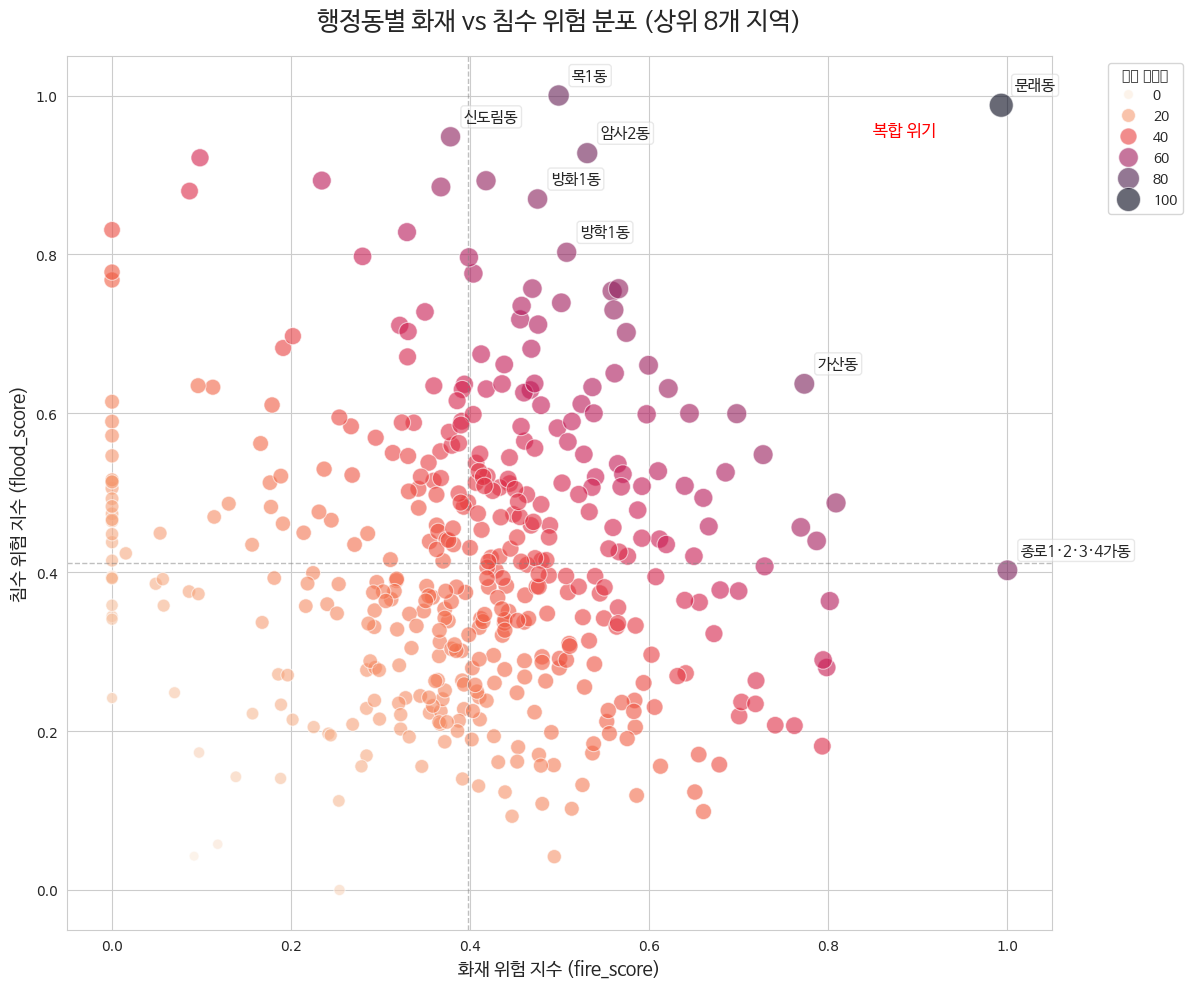

In [ ]:
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# 1. 산점도 그리기
scatter = sns.scatterplot(
    data=disaster_df,
    x='fire_score',
    y='flood_score',
    size='DISASTER_SCORE',
    hue='DISASTER_SCORE',
    palette='rocket_r',
    sizes=(50, 300),
    alpha=0.6
)

# 3. 평균선 추가
avg_fire = disaster_df['fire_score'].mean()
avg_flood = disaster_df['flood_score'].mean()
plt.axvline(avg_fire, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(avg_flood, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# 4. 텍스트 위치 최적화 (수동 오프셋 계산)
# 데이터의 전체 범위를 파악하여 여백 비율을 정합니다.
x_range = disaster_df['fire_score'].max() - disaster_df['fire_score'].min()
y_range = disaster_df['flood_score'].max() - disaster_df['flood_score'].min()

# 상위 8개 위험 지역 추출
top_disasters = disaster_df.sort_values('DISASTER_SCORE', ascending=False).head(8)

for i in range(len(top_disasters)):
    row = top_disasters.iloc[i]

    # 텍스트가 점의 정중앙에 오지 않도록 살짝 띄움 (범위의 2% 정도)
    plt.text(
        row['fire_score'] + (x_range * 0.015),
        row['flood_score'] + (y_range * 0.015),
        row['행정동'],
        fontproperties=font_prop,
        fontsize=11,
        fontweight='bold',
        va='bottom', # 수직 정렬: 아래쪽 기준
        ha='left',   # 수평 정렬: 왼쪽 기준
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='lightgray', boxstyle='round,pad=0.2') # 가독성을 위한 배경박스
    )

# 5. 축 및 타이틀 설정
plt.title('행정동별 화재 vs 침수 위험 분포 (상위 8개 지역)', fontproperties=fm.FontProperties(fname=font_path, size=18), pad=20)
plt.xlabel('화재 위험 지수 (fire_score)', fontproperties=font_prop, fontsize=13)
plt.ylabel('침수 위험 지수 (flood_score)', fontproperties=font_prop, fontsize=13)

# 사분면 설명 추가
plt.text(disaster_df['fire_score'].max()*0.85, disaster_df['flood_score'].max()*0.95, '복합 위기',
         fontproperties=font_prop, color='red', fontsize=12, fontweight='bold')

plt.legend(prop=font_prop, bbox_to_anchor=(1.05, 1), loc='upper left', title='종합 위험도')
plt.tight_layout()
plt.show()

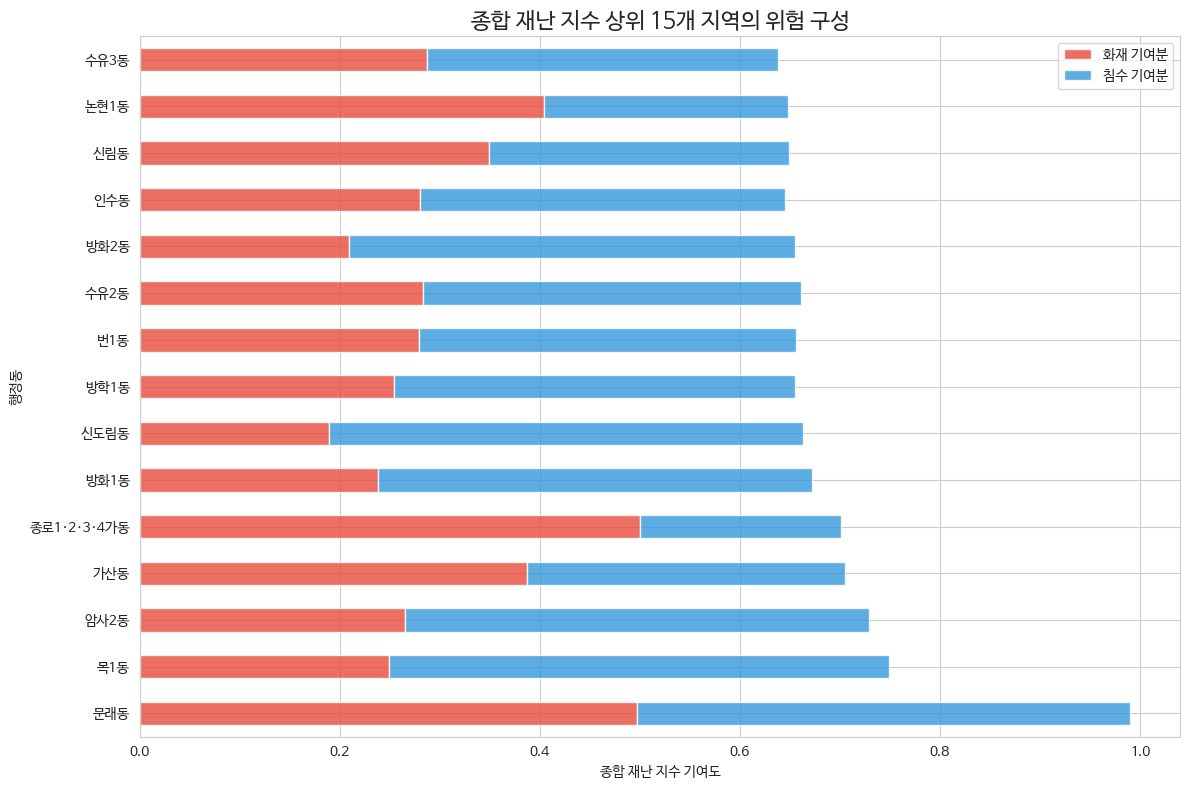

In [ ]:
# 상위 15개 지역 추출
top_15_df = disaster_df.sort_values('DISASTER_SCORE', ascending=False).head(15)

# 시각화를 위한 데이터 재구성 (가중치 0.5 반영 상태를 시각적으로 표현)
top_15_df['fire_part'] = top_15_df['fire_score'] * 0.5
top_15_df['flood_part'] = top_15_df['flood_score'] * 0.5

ax = top_15_df.plot(
    x='행정동',
    y=['fire_part', 'flood_part'],
    kind='barh',
    stacked=True,
    figsize=(12, 8),
    color=['#e74c3c', '#3498db'],
    alpha=0.8
)

plt.title('종합 재난 지수 상위 15개 지역의 위험 구성', fontproperties=fm.FontProperties(fname=font_path, size=16))
plt.xlabel('종합 재난 지수 기여도', fontproperties=font_prop)
plt.ylabel('행정동', fontproperties=font_prop)
plt.legend(['화재 기여분', '침수 기여분'], prop=font_prop)
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

plt.tight_layout()
plt.show()

In [ ]:
import folium

# 서울 중심부 설정
m_disaster_overlay = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 1. 배경 레이어 (Base): 종합 재난 지수 (Choropleth)
# 위험 수준에 따라 'YlOrRd' (노랑-주황-빨강) 색상 적용
folium.Choropleth(
    geo_data=disaster_gdf_4326,
    data=disaster_gdf_4326,
    columns=['행정동', 'DISASTER_SCORE'],
    key_on='feature.properties.행정동',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='종합 재난 위험 지수 (DISASTER_SCORE)'
).add_to(m_disaster_overlay)

# 2. 오버레이 레이어 (Overlay): 화재/침수 위험 지역 강조
# 화재 점수 상위 10%, 침수 점수 상위 10% 지역 추출
fire_threshold = disaster_gdf_4326['fire_score'].quantile(0.9)
flood_threshold = disaster_gdf_4326['flood_score'].quantile(0.9)

high_fire = disaster_gdf_4326[disaster_gdf_4326['fire_score'] >= fire_threshold]
high_flood = disaster_gdf_4326[disaster_gdf_4326['flood_score'] >= flood_threshold]

# 화재 고위험 지역 추가 (빨간색 테두리)
folium.GeoJson(
    high_fire,
    name='화재 고위험 지역 (상위 10%)',
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'red',
        'weight': 2,
        'fillOpacity': 0.1 # 테두리만 강조하기 위해 칠하기 투명도 낮춤
    }
).add_to(m_disaster_overlay)

# 침수 고위험 지역 추가 (파란색 테두리)
folium.GeoJson(
    high_flood,
    name='침수 고위험 지역 (상위 10%)',
    style_function=lambda x: {
        'fillColor': 'blue',
        'color': 'blue',
        'weight': 2,
        'fillOpacity': 0.1
    }
).add_to(m_disaster_overlay)

# 레이어 컨트롤 추가
folium.LayerControl().add_to(m_disaster_overlay)

# 결과 저장 및 출력
m_disaster_overlay.save('seoul_disaster_overlay_map.html')
m_disaster_overlay

Output hidden; open in https://colab.research.google.com to view.

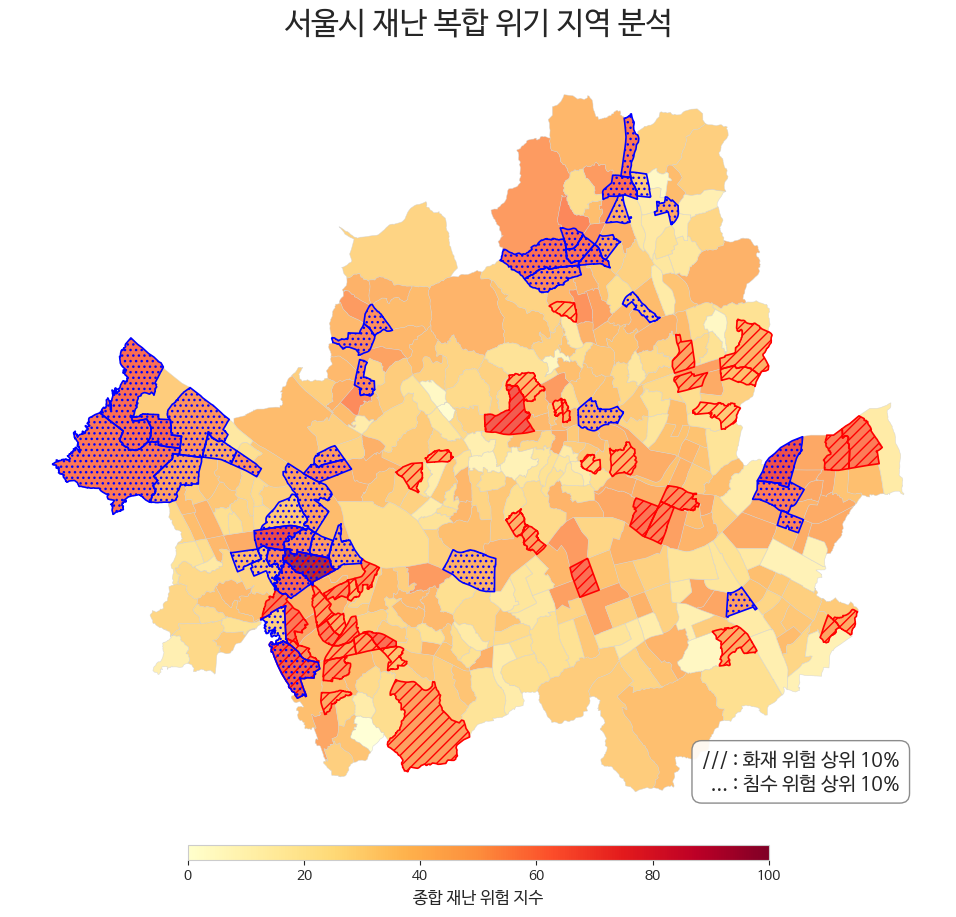

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.font_manager as fm

# 1. 폰트 경로 정의 (코랩 표준 경로)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
# 개별 요소에 적용할 폰트 객체 생성
font_p = fm.FontProperties(fname=font_path)

# 2. 데이터 준비 (상위 10% 추출)
fire_threshold = disaster_gdf['fire_score'].quantile(0.9)
flood_threshold = disaster_gdf['flood_score'].quantile(0.9)
high_fire = disaster_gdf[disaster_gdf['fire_score'] >= fire_threshold]
high_flood = disaster_gdf[disaster_gdf['flood_score'] >= flood_threshold]

# 3. 시각화
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# (1) 배경: 종합 재난 지수
disaster_gdf.plot(
    column='DISASTER_SCORE',
    cmap='YlOrRd',
    ax=ax,
    edgecolor='lightgray',
    linewidth=0.4,
    alpha=0.8
)

# (2) 오버레이: 화재(빗금) 및 침수(점)
high_fire.plot(ax=ax, facecolor="none", edgecolor="red", hatch="///", linewidth=1.2)
high_flood.plot(ax=ax, facecolor="none", edgecolor="blue", hatch="...", linewidth=1.2)

# (3) 텍스트 요소 하나하나에 폰트 직접 주입
# 제목 설정
ax.set_title('서울시 재난 복합 위기 지역 분석', fontproperties=fm.FontProperties(fname=font_path, size=22), pad=20)

# 범례 역할을 하는 텍스트 박스
legend_text = '/// : 화재 위험 상위 10%\n... : 침수 위험 상위 10%'
ax.text(0.95, 0.05, legend_text,
        transform=ax.transAxes,
        fontproperties=fm.FontProperties(fname=font_path, size=14),
        fontweight='bold',
        ha='right',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

# 컬러바(Colorbar) 수동 설정 (폰트 깨짐 방지)
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=disaster_gdf['DISASTER_SCORE'].min(), vmax=disaster_gdf['DISASTER_SCORE'].max()))
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=40, shrink=0.5)
cbar.set_label('종합 재난 위험 지수', fontproperties=font_p, fontsize=12)
for label in cbar.ax.get_xticklabels():
    label.set_fontproperties(font_p)

ax.set_axis_off()
plt.show()